In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#final
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
import rasterio
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler
import cv2
from tensorflow.keras import layers, models
#from keras_radam import RAdam

# Step 1: Load Bands from Disk
band_paths = [
    '/content/drive/MyDrive/model/bands/L8_2024_01_SR_B1.tif',  # Aerosol
    '/content/drive/MyDrive/model/bands/L8_2024_01_SR_B2.tif',  # Blue
    '/content/drive/MyDrive/model/bands/L8_2024_01_SR_B3.tif',  # Green
    '/content/drive/MyDrive/model/bands/L8_2024_01_SR_B4.tif',  # Red
    '/content/drive/MyDrive/model/bands/L8_2024_01_SR_B5.tif',  # NIR
    '/content/drive/MyDrive/model/bands/L8_2024_01_SR_B6.tif',  # SWIR1
    '/content/drive/MyDrive/model/bands/L8_2024_01_SR_B7.tif',  # SWIR2
]

bands = []
for path in band_paths:
    with rasterio.open(path) as src:
        bands.append(src.read(1).astype(np.float32))  # Read as float32 for processing
        transform = src.transform
# Stack bands into a 3D array (Height x Width x Bands)
stacked_image = np.stack(bands, axis=-1)  # Shape: (H, W, 7)

In [12]:

# # Step 1.1: Apply Image Enhancement Methods
# def contrast_stretching(image):
#     min_val = np.min(image)
#     max_val = np.max(image)
#     if max_val > min_val:  # Avoid division by zero
#         return ((image - min_val) * 255 / (max_val - min_val)).clip(0, 255).astype(np.uint8)
#     return image

# def unsharp_masking(image):
#     gaussian = cv2.GaussianBlur(image, (5, 5), 1.0)
#     return cv2.addWeighted(image, 1.5, gaussian, -0.5, 0)

# def histogram_equalization(image):
#     return cv2.equalizeHist(image.astype(np.uint8))

# def clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
#     clahe_obj = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
#     return clahe_obj.apply(image.astype(np.uint8))

# # Apply enhancements to each band
# enhanced_bands = np.zeros_like(stacked_image, dtype=np.uint8)
# for band_idx in range(stacked_image.shape[2]):
#     band = stacked_image[:,:,band_idx]
#     # Apply contrast stretching first to set range
#     stretched = contrast_stretching(band)
#     # Apply unsharp masking
#     sharpened = unsharp_masking(stretched)
#     # Apply histogram equalization
#     equalized = histogram_equalization(sharpened)
#     # Apply CLAHE
#     enhanced = clahe(equalized)
#     enhanced_bands[:,:,band_idx] = enhanced

# stacked_image = enhanced_bands  # Replace original with enhanced image
# print(stacked_image.shape)

def clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe_obj = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe_obj.apply(image.astype(np.uint8))

# Apply CLAHE only
enhanced_bands = np.zeros_like(stacked_image, dtype=np.uint8)
for band_idx in range(stacked_image.shape[2]):
    band = stacked_image[:, :, band_idx]

    # Optional: contrast stretch to 8-bit if original band values are outside [0,255]
    band_min, band_max = band.min(), band.max()
    if band_max > band_min:
        band_8bit = ((band - band_min) * 255 / (band_max - band_min)).astype(np.uint8)
    else:
        band_8bit = band.astype(np.uint8)

    enhanced = clahe(band_8bit)
    enhanced_bands[:, :, band_idx] = enhanced

stacked_image = enhanced_bands  # Overwrite with CLAHE-enhanced image
print("Enhanced shape:", stacked_image.shape)


Enhanced shape: (1085, 1795, 7)


In [13]:
with rasterio.open("/content/drive/MyDrive/model/DW_WaterMask_202401.tif") as mask_src:
    water_mask = mask_src.read(1)  # Shape: (H, W), values 0 and 1
    mask_transform = mask_src.transform
    mask_crs = mask_src.crs


In [14]:
assert water_mask.shape == stacked_image.shape[:2]


In [15]:
# def generate_training_patches(image, mask, patch_size=9, max_samples_per_class=50000):
#     half = patch_size // 2
#     h, w, c = image.shape

#     water_patches = []
#     nonwater_patches = []

#     for i in range(half, h - half):
#         for j in range(half, w - half):
#             label = mask[i, j]
#             patch = image[i - half:i + half + 1, j - half:j + half + 1, :]
#             if patch.shape != (patch_size, patch_size, c):
#                 continue
#             if label == 1 and len(water_patches) < max_samples_per_class:
#                 water_patches.append((patch, 1))
#             elif label == 0 and len(nonwater_patches) < max_samples_per_class:
#                 nonwater_patches.append((patch, 0))

#     # Combine and shuffle
#     all_data = water_patches + nonwater_patches
#     np.random.shuffle(all_data)
#     X, y = zip(*all_data)
#     return np.array(X), np.array(y)

# X_patches, y_patches = generate_training_patches(stacked_image, water_mask, patch_size=9)
# X_patches = X_patches.astype(np.float32) / 255.0  # Normalize



import geopandas as gpd
from shapely.geometry import Point

# Load labeled point data (e.g., with 'class' column: 1=water, 0=non-water)
gdf = gpd.read_file("/content/drive/MyDrive/model/training points/testing.geojson")
gdf = gdf.dropna(subset=['class'])
gdf = gdf.to_crs(mask_crs)  # Match raster CRS
gdf['class'] = gdf['class'].map({0: 1, 1: 0})

def generate_patches_from_points(image, gdf, patch_size=9):
    half = patch_size // 2
    h, w, c = image.shape
    patches = []
    labels = []

    for idx, row in gdf.iterrows():
        x, y = row.geometry.x, row.geometry.y
        label = int(row['class'])  # You must have a 'class' column in the GeoJSON

        # Convert coordinates to raster row/col
        col, row_r = ~transform * (x, y)
        col, row_r = int(round(col)), int(round(row_r))

        # Check bounds
        if (row_r - half < 0 or row_r + half >= h or
            col - half < 0 or col + half >= w):
            continue

        patch = image[row_r - half:row_r + half + 1, col - half:col + half + 1, :]
        if patch.shape == (patch_size, patch_size, c):
            patches.append(patch)
            labels.append(label)

    return np.array(patches), np.array(labels)

X_patches, y_patches = generate_patches_from_points(stacked_image, gdf, patch_size=9)
X_patches = X_patches.astype(np.float32) / 255.0  # Normalize

print("Extracted patches:", X_patches.shape)


Extracted patches: (4098, 9, 9, 7)


In [16]:
# from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(
#     X_patches, y_patches, test_size=0.2, stratify=y_patches, random_state=42)
# patch_size = 9

from sklearn.model_selection import train_test_split

# First split into 80% train and 20% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_patches, y_patches, test_size=0.2, stratify=y_patches, random_state=42
)

# Then split temp into 50% val and 50% test → 10% each of total data
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

patch_size = 9

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


Train set: (3278, 9, 9, 7) (3278,)
Validation set: (410, 9, 9, 7) (410,)
Test set: (410, 9, 9, 7) (410,)


In [17]:
# from tensorflow.keras import layers, models, regularizers
# import tensorflow as tf
# #msa-wdnet
# from tensorflow.keras import layers, models, regularizers

# def build_msa_wdnet(input_shape, l2_strength=1e-4):
#     inputs = layers.Input(shape=input_shape)
#     l2 = regularizers.l2(l2_strength)
#     branch1 = layers.Conv2D(16, (3, 3), padding='same', activation='relu',
#                             kernel_regularizer=l2)(inputs)
#     branch1 = layers.Conv2D(16, (3, 3), padding='same', activation='relu',
#                             kernel_regularizer=l2)(branch1)

#     branch2 = layers.Conv2D(16, (5, 5), padding='same', activation='relu',
#                             kernel_regularizer=l2)(inputs)
#     branch2 = layers.Conv2D(16, (5, 5), padding='same', activation='relu',
#                             kernel_regularizer=l2)(branch2)

#     branch3 = layers.Conv2D(16, (7, 7), padding='same', activation='relu',
#                             kernel_regularizer=l2)(inputs)
#     branch3 = layers.Conv2D(16, (7, 7), padding='same', activation='relu',
#                             kernel_regularizer=l2)(branch3)


#     # Feature Fusion
#     multiscale = layers.Concatenate()([branch1, branch2, branch3])
#     multiscale = layers.BatchNormalization()(multiscale)

#     # Squeeze-and-Excitation Attention
#     squeeze = layers.GlobalAveragePooling2D()(multiscale)
#     excitation = layers.Dense(64, activation='relu', kernel_regularizer=l2)(squeeze)
#     excitation = layers.Dense(multiscale.shape[-1], activation='sigmoid',
#                               kernel_regularizer=l2)(excitation)
#     excitation = layers.Reshape((1, 1, multiscale.shape[-1]))(excitation)
#     attended = layers.Multiply()([multiscale, excitation])

#     # Classification Head
#     x = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
#                       kernel_regularizer=l2)(attended)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(64, activation='relu', kernel_regularizer=l2)(x)
#     x = layers.Dropout(0.4)(x)  # slightly increased dropout
#     outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=l2)(x)

#     return models.Model(inputs=inputs, outputs=outputs)

# # model = build_msa_wdnet(input_shape=(patch_size, patch_size, 7))
# # model.summary()

from tensorflow.keras import layers, models, regularizers

def build_msa_wdnet_improved(input_shape, l2_strength=1e-4, dropout_rate=0.4, spatial_dropout=0.15):
    """
    Improved MSA-WDNet (binary classification).
    - Multiscale branches (3x3,5x5,7x7)
    - SE (squeeze-and-excitation) attention
    - Encoder with two downsampling stages + a dilated conv for larger context
    - Feature fusion: global pooled encoder features + global pooled attended features (skip)
    - Stronger regularization: BatchNorm, SpatialDropout2D, Dropout, L2
    """

    inputs = layers.Input(shape=input_shape)
    l2 = regularizers.l2(l2_strength)

    # --- Multiscale branches (each has two convs) ---
    branch1 = layers.Conv2D(16, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(inputs)
    branch1 = layers.BatchNormalization()(branch1)
    branch1 = layers.Conv2D(16, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(branch1)
    branch1 = layers.BatchNormalization()(branch1)

    branch2 = layers.Conv2D(16, (5,5), padding='same', activation='relu', kernel_regularizer=l2)(inputs)
    branch2 = layers.BatchNormalization()(branch2)
    branch2 = layers.Conv2D(16, (5,5), padding='same', activation='relu', kernel_regularizer=l2)(branch2)
    branch2 = layers.BatchNormalization()(branch2)

    branch3 = layers.Conv2D(16, (7,7), padding='same', activation='relu', kernel_regularizer=l2)(inputs)
    branch3 = layers.BatchNormalization()(branch3)
    branch3 = layers.Conv2D(16, (7,7), padding='same', activation='relu', kernel_regularizer=l2)(branch3)
    branch3 = layers.BatchNormalization()(branch3)

    # Feature fusion
    multiscale = layers.Concatenate()([branch1, branch2, branch3])  # channels = 48
    multiscale = layers.BatchNormalization()(multiscale)
    multiscale = layers.SpatialDropout2D(spatial_dropout)(multiscale)

    # --- Squeeze-and-Excitation attention ---
    squeeze = layers.GlobalAveragePooling2D()(multiscale)
    excitation = layers.Dense(max(32, int(squeeze.shape[-1]//4)), activation='relu', kernel_regularizer=l2)(squeeze)
    excitation = layers.Dense(int(multiscale.shape[-1]), activation='sigmoid', kernel_regularizer=l2)(excitation)
    excitation = layers.Reshape((1, 1, int(multiscale.shape[-1])))(excitation)
    attended = layers.Multiply()([multiscale, excitation])  # same spatial dims as multiscale

    # --- Shallow encoder (adds depth / hierarchy like WNet) ---
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(attended)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)   # spatial down  -> good for small patches: only 1st pooling

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)   # spatial down again -> at most 2 poolings

    # Dilated convolution to increase receptive field without extra pooling
    x = layers.Conv2D(128, (3,3), dilation_rate=2, padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)

    # --- Global pooling of encoder features ---
    encoder_global = layers.GlobalAveragePooling2D()(x)

    # --- Also pool the attended multiscale features as a skip-global feature (preserves fine details) ---
    attended_global = layers.GlobalAveragePooling2D()(attended)

    # --- Merge both global descriptors (coarse + fine) ---
    merged = layers.Concatenate()([encoder_global, attended_global])
    merged = layers.Dense(128, activation='relu', kernel_regularizer=l2)(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(dropout_rate)(merged)

    merged = layers.Dense(64, activation='relu', kernel_regularizer=l2)(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(dropout_rate * 0.75)(merged)

    # Output (binary)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=l2)(merged)

    model = models.Model(inputs=inputs, outputs=outputs, name='msa_wdnet_improved')
    return model



patch_size = 9   # or 15, 32, 64 — choose according to your extraction
model = build_msa_wdnet_improved(input_shape=(patch_size, patch_size, 7))
model.summary()

#waternet
def build_wnet_exact(input_shape=(9, 9, 7)):

    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)  # -> (4x4x32)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)  # -> (2x2x64)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)  # -> (1x1x128)

    # Flatten
    x = layers.Flatten()(x)

    # 16-18: Fully‐connected layers
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    # 19. Output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model
# model = build_wnet_exact(input_shape=(patch_size, patch_size, 7))
# model.summary()

Model: "msa_wdnet_improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9, 9, 7)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 9, 9, 16)  │      1,024 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 9, 9, 16)  │      2,816 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 9, 9, 16)  │      5,504 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 9, 9, 16)  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 16)  │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 16)  │         64 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 9, 9, 16)  │      2,320 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 9, 9, 16)  │      6,416 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 9, 9, 16)  │     12,560 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 16)  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 16)  │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 16)  │         64 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9, 9, 48)  │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 48)  │        192 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 9, 9, 48)  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ spatial_dropout2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,568 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 48)        │      1,584 │ dense[0][0]     

 Total params: 316,545 (1.21 MB)

 Trainable params: 315,233 (1.20 MB)

 Non-trainable params: 1,312 (5.12 KB)

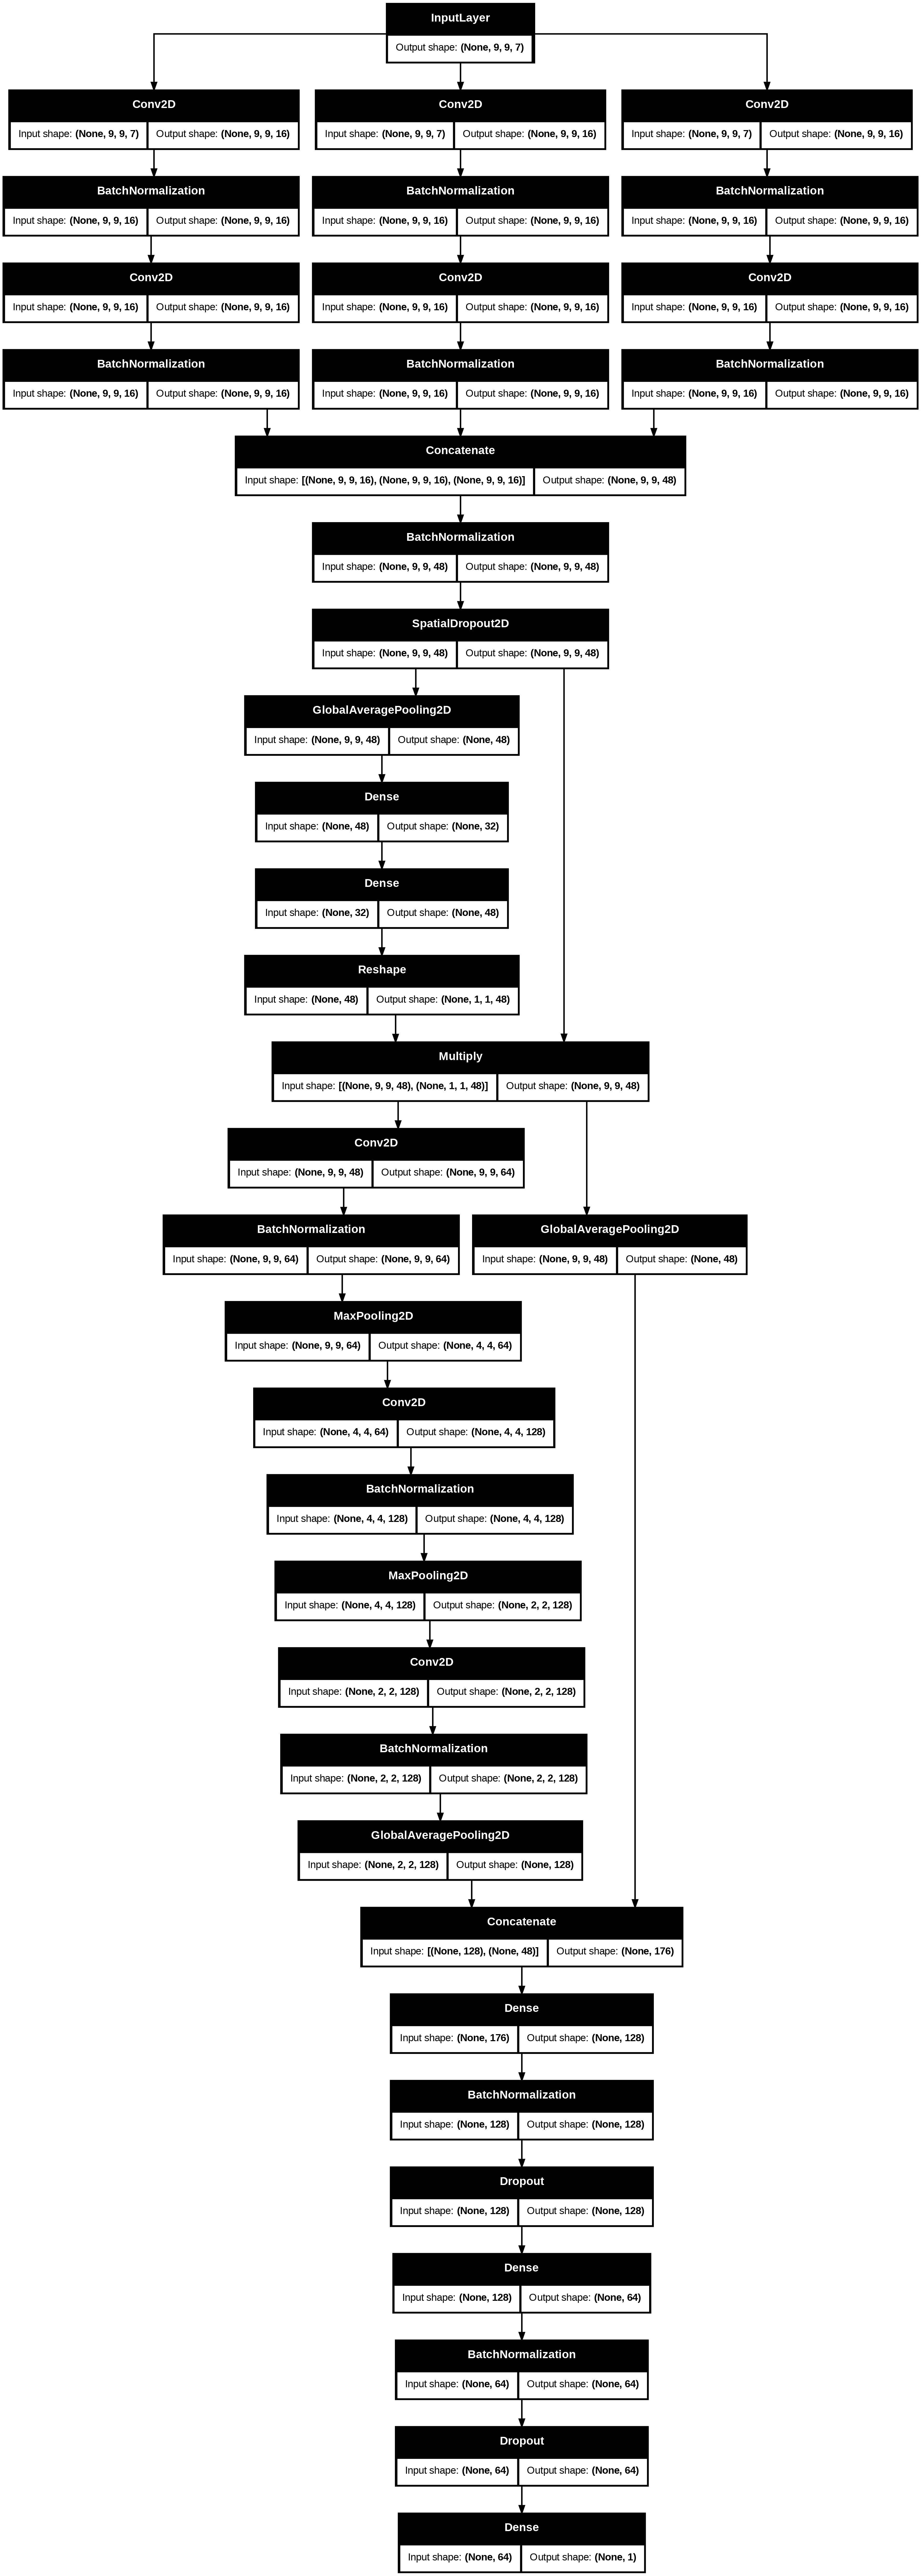

In [18]:
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file='msa_wdnet_architecture.png',
    show_shapes=True,
    dpi=200
)

In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',  # Use BCE instead of focal
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

early_stop = EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)

# history=model.fit(X_train, y_train,
#           validation_data=(X_val, y_val),
#           epochs=50,
#           batch_size=32,
#           callbacks=[early_stop],
#           verbose=1)  # no class weights


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.8225 - auc: 0.8982 - loss: 0.4788 - recall: 0.8237 - val_accuracy: 0.4829 - val_auc: 0.9167 - val_loss: 0.7766 - val_recall: 0.0000e+00
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.8853 - auc: 0.9443 - loss: 0.3588 - recall: 0.8970 - val_accuracy: 0.4829 - val_auc: 0.9433 - val_loss: 0.8880 - val_recall: 0.0000e+00
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9054 - auc: 0.9587 - loss: 0.3113 - recall: 0.9213 - val_accuracy: 0.7000 - val_auc: 0.9656 - val_loss: 0.5720 - val_recall: 0.4198
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9161 - auc: 0.9658 - loss: 0.2857 - recall: 0.9314 - val_accuracy: 0.8488 - val_auc: 0.9694 - val_loss: 0.3595 - val_recall: 0.7500
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.9295 - auc: 0.9713 - loss: 0.2576 - recall: 0.9521 - val_accuracy: 0.9244 - val_auc: 0.9771 - val_loss: 0.2457 - val_recall: 0

In [20]:
model.save("/content/drive/MyDrive/model/msa.h5")  # HDF5 format


In [21]:
# Test Evaluation
from tensorflow.keras.models import load_model
# === Load the saved model ===
model_path = "/content/drive/MyDrive/model/msa.h5"  # Change to your saved model path
model = load_model(model_path, compile=False)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, confusion_matrix, classification_report, roc_auc_score

y_test_probs = model.predict(X_test, verbose=0).flatten()
y_test_pred = (y_test_probs > 0.32).astype(int)

acc_test = accuracy_score(y_test, y_test_pred)
prec_test = precision_score(y_test, y_test_pred)
rec_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
iou_test = jaccard_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_probs)

print("\n=== Final Test Set Metrics ===")
print(f"Accuracy: {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall: {rec_test:.4f}")
print(f"F1 Score: {f1_test:.4f}")
print(f"IoU: {iou_test:.4f}")
print(f"ROC AUC: {roc_auc_test:.4f}")



=== Final Test Set Metrics ===
Accuracy: 0.9366
Precision: 0.8970
Recall: 0.9905
F1 Score: 0.9414
IoU: 0.8894
ROC AUC: 0.9753


In [12]:
import numpy as np
from tqdm import tqdm

def predict_full_image(image, model, patch_size=9, batch_size=512):
    h, w, c = image.shape
    half = patch_size // 2
    pred_map = np.zeros((h, w), dtype=np.uint8)
    padded = np.pad(image, ((half, half), (half, half), (0, 0)), mode='reflect')

    patches = []
    coords = []

    for i in tqdm(range(half, h + half), desc="Predicting rows"):
        for j in range(half, w + half):
            patch = padded[i - half:i + half + 1, j - half:j + half + 1, :]
            patch = patch.astype(np.float32) / 255.0
            patches.append(patch)
            coords.append((i - half, j - half))

            # Predict in batches
            if len(patches) == batch_size:
                preds = (model.predict(np.array(patches), verbose=0) > 0.55).astype(np.uint8)
                for (x, y), p in zip(coords, preds):
                    pred_map[x, y] = p.item()
                patches, coords = [], []

    # Final remaining patches
    if patches:
        preds = (model.predict(np.array(patches), verbose=0) > 0.55).astype(np.uint8)
        for (x, y), p in zip(coords, preds):
            pred_map[x, y] = p.item()

    return pred_map


In [23]:
import matplotlib.pyplot as plt
# Call the function and store the result
pred_map = predict_full_image(stacked_image, model, patch_size=9)

Predicting rows: 100%|██████████| 1085/1085 [25:46<00:00,  1.43s/it]


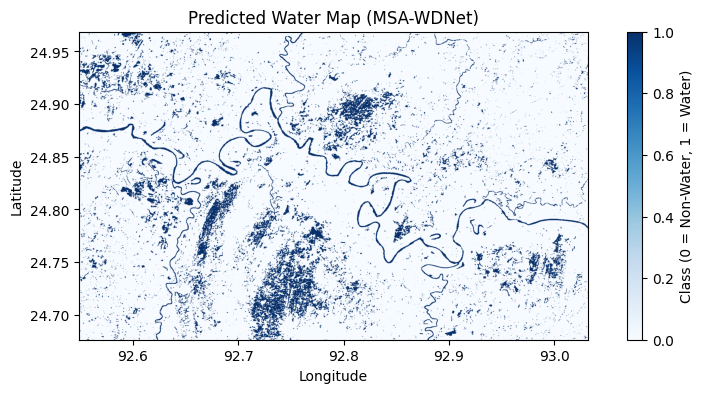

<Figure size 640x480 with 0 Axes>

In [24]:

# You already have `transform` from reading your original raster
plt.figure(figsize=(10, 4))
plt.imshow(pred_map, cmap='Blues',
           extent=(transform[2], transform[2] + transform[0] * stacked_image.shape[1],
                   transform[5] + transform[4] * stacked_image.shape[0], transform[5]))
plt.title("Predicted Water Map (MSA-WDNet)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='Class (0 = Non-Water, 1 = Water)')
plt.show()
plt.savefig("/content/drive/MyDrive/model/out/Predicted_Water_Map(MSA_WDNet).png", dpi=300)

In [25]:
#validation evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, confusion_matrix, classification_report
y_pred_probs = model.predict(X_val)  # Outputs probabilities
y_pred = (y_pred_probs > 0.55).astype(int).flatten()  # Binarize at threshold 0.5
# Binary classification
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
iou = jaccard_score(y_val, y_pred)

cm = confusion_matrix(y_val, y_pred)
report = classification_report(y_val, y_pred, target_names=["Non-Water", "Water"])

print("=== Evaluation Metrics ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"IoU (Jaccard Index): {iou:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
=== Evaluation Metrics ===
Accuracy: 0.9366
Precision: 0.9306
Recall: 0.9481
F1 Score: 0.9393
IoU (Jaccard Index): 0.8855

Confusion Matrix:
[[183  15]
 [ 11 201]]

Classification Report:
              precision    recall  f1-score   support

   Non-Water       0.94      0.92      0.93       198
       Water       0.93      0.95      0.94       212

    accuracy                           0.94       410
   macro avg       0.94      0.94      0.94       410
weighted avg       0.94      0.94      0.94       410



In [26]:
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, confusion_matrix, classification_report
import numpy as np

# === Load the saved model ===
model_path = "/content/drive/MyDrive/model/msa.h5"  # Change to your saved model path
model = load_model(model_path, compile=False)

# === Load or prepare your validation data ===
# Make sure X_val and y_val are loaded exactly the same way as during training
# Example:
# X_val = np.load("X_val.npy")
# y_val = np.load("y_val.npy")

# === Predict and evaluate ===
y_pred_probs = model.predict(X_val)  # Outputs probabilities
y_pred = (y_pred_probs > 0.55).astype(int).flatten()  # Apply threshold

# Binary classification metrics
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
iou = jaccard_score(y_val, y_pred)

cm = confusion_matrix(y_val, y_pred)
report = classification_report(y_val, y_pred, target_names=["Non-Water", "Water"])

# === Print results ===
print("=== Evaluation Metrics ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"IoU (Jaccard Index): {iou:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
=== Evaluation Metrics ===
Accuracy: 0.9366
Precision: 0.9306
Recall: 0.9481
F1 Score: 0.9393
IoU (Jaccard Index): 0.8855

Confusion Matrix:
[[183  15]
 [ 11 201]]

Classification Report:
              precision    recall  f1-score   support

   Non-Water       0.94      0.92      0.93       198
       Water       0.93      0.95      0.94       212

    accuracy                           0.94       410
   macro avg       0.94      0.94      0.94       410
weighted avg       0.94      0.94      0.94       410



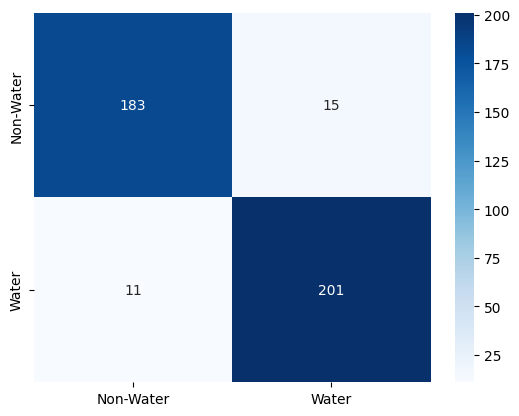

<Figure size 640x480 with 0 Axes>

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Water", "Water"], yticklabels=["Non-Water", "Water"])
plt.show()
plt.savefig("/content/drive/MyDrive/model/out/confusionb.png", dpi=300)

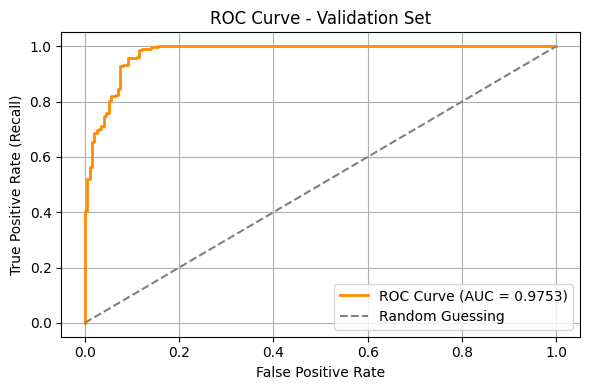

ROC AUC Score: 0.9753


<Figure size 640x480 with 0 Axes>

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 1: Predict probabilities on validation set
y_val_probs = model.predict(X_test, verbose=0).flatten()

# Step 2: Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = roc_auc_score(y_test, y_test_probs)

# Step 3: Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Print AUC value
print(f"ROC AUC Score: {roc_auc:.4f}")
plt.savefig("/content/drive/MyDrive/model/out/Roc.png", dpi=300)

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ===== TRAIN ROC =====
y_train_probs = model.predict(X_train, verbose=0).flatten()
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_probs)
auc_train = roc_auc_score(y_train, y_train_probs)


# ===== VALIDATION ROC =====
y_val_probs = model.predict(X_val, verbose=0).flatten()
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_probs)
auc_val = roc_auc_score(y_val, y_val_probs)


# ===== TEST ROC =====
y_test_probs = model.predict(X_test, verbose=0).flatten()
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = roc_auc_score(y_test, y_test_probs)

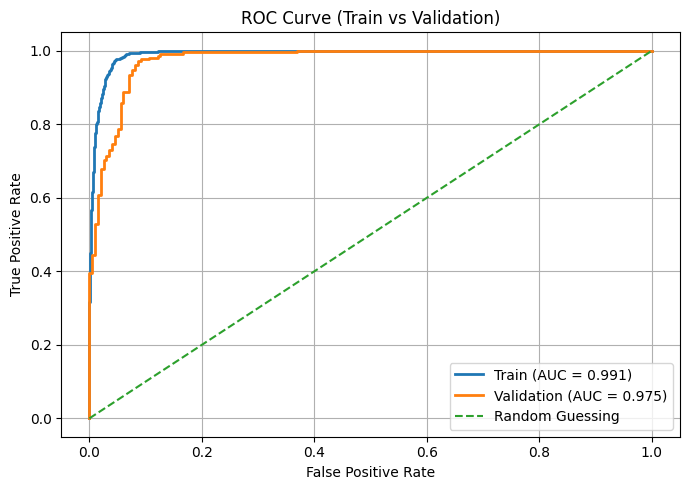

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize=(7,5))

# Train
plt.plot(fpr_train, tpr_train,
         label=f'Train (AUC = {auc_train:.3f})', linewidth=2)

# Validation
plt.plot(fpr_val, tpr_val,
         label=f'Validation (AUC = {auc_val:.3f})', linewidth=2)

# Random guessing
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guessing')

# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Train vs Validation)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/model/out/RocTV.png", dpi=300)

In [35]:
# Ensure 'class' column exists
if 'class' not in gdf.columns:
    raise ValueError("GeoDataFrame does not contain a 'class' column.")

# Count total number of points
total_points = len(gdf)

# Count each class
class_counts = gdf['class'].value_counts().sort_index()  # Sort by class 0, 1

# Extract counts
non_water_count = class_counts.get(0, 0)
water_count = class_counts.get(1, 0)

# Print results
print("=== Point Label Statistics ===")
print(f"Total Points     : {total_points}")
print(f"Non-Water Points : {non_water_count}")
print(f"Water Points     : {water_count}")


=== Point Label Statistics ===
Total Points     : 4140
Non-Water Points : 2010
Water Points     : 2130


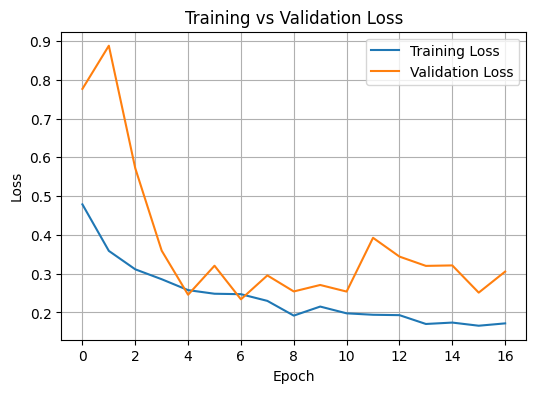

<Figure size 640x480 with 0 Axes>

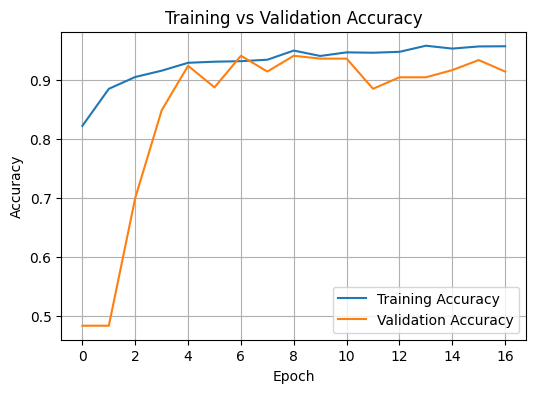

<Figure size 640x480 with 0 Axes>

In [37]:
# === Plot Loss Curve ===
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("/content/drive/MyDrive/model/out/TvsVL.png", dpi=300)
# === Plot Accuracy Curve ===
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("/content/drive/MyDrive/model/out/TvsVA.png", dpi=300)

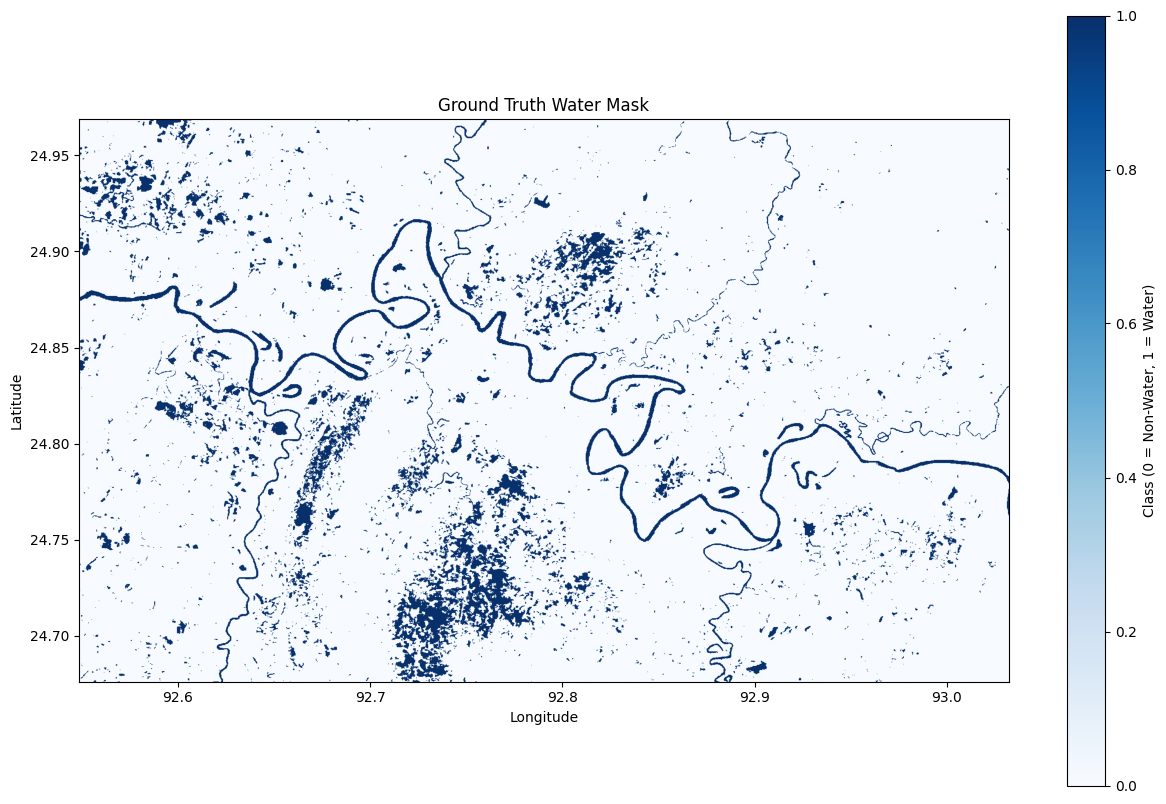

<Figure size 640x480 with 0 Axes>

In [38]:
plt.figure(figsize=(15, 10))
plt.imshow(water_mask, cmap='Blues',
           extent=(transform[2], transform[2] + transform[0] * stacked_image.shape[1],
                   transform[5] + transform[4] * stacked_image.shape[0], transform[5]))
plt.title("Ground Truth Water Mask")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='Class (0 = Non-Water, 1 = Water)')
plt.show()
plt.savefig("/content/drive/MyDrive/model/out/GTWM.png", dpi=300)

Testing on New Dataset (Barak)

In [3]:
# NEW DATASET (Barak Sentinel)
band_paths_new = [
    '/content/drive/MyDrive/model/SEN_30_Barak/JAN_2026_30m_B1.tif',
    '/content/drive/MyDrive/model/SEN_30_Barak/JAN_2026_30m_B2.tif',
    '/content/drive/MyDrive/model/SEN_30_Barak/JAN_2026_30m_B3.tif',
    '/content/drive/MyDrive/model/SEN_30_Barak/JAN_2026_30m_B4.tif',
    '/content/drive/MyDrive/model/SEN_30_Barak/JAN_2026_30m_B8.tif',
    '/content/drive/MyDrive/model/SEN_30_Barak/JAN_2026_30m_B11.tif',
    '/content/drive/MyDrive/model/SEN_30_Barak/JAN_2026_30m_B12.tif',
]

bands_new = []
for path in band_paths_new:
    with rasterio.open(path) as src:
        bands_new.append(src.read(1).astype(np.float32))
        transform_new = src.transform
        crs_new = src.crs

stacked_new = np.stack(bands_new, axis=-1)
print("New image shape:", stacked_new.shape)

New image shape: (1170, 1886, 7)


In [4]:
#Apply CLAHE

In [5]:
def clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    return cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size).apply(image)

enhanced_new = np.zeros_like(stacked_new, dtype=np.uint8)

for i in range(stacked_new.shape[2]):
    band = stacked_new[:, :, i]

    band_min, band_max = band.min(), band.max()
    if band_max > band_min:
        band_8bit = ((band - band_min) * 255 / (band_max - band_min)).astype(np.uint8)
    else:
        band_8bit = band.astype(np.uint8)

    enhanced_new[:, :, i] = clahe(band_8bit)

stacked_new = enhanced_new

In [6]:
#Load

In [7]:
with rasterio.open("/content/drive/MyDrive/model/SEN_30_Barak/Barak_DW_WaterMask_Exact.tif") as src:
    water_mask_new = src.read(1)

print("Mask shape:", water_mask_new.shape)
print("Image shape:", stacked_new.shape[:2])

Mask shape: (1171, 1886)
Image shape: (1170, 1886)


In [8]:
import cv2

if water_mask_new.shape != stacked_new.shape[:2]:
    water_mask_new = cv2.resize(
        water_mask_new,
        (stacked_new.shape[1], stacked_new.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

In [9]:
def generate_training_patches(image, mask, patch_size=9):
    half = patch_size // 2
    h, w, c = image.shape

    patches = []
    labels = []

    for i in range(half, h - half):
        for j in range(half, w - half):

            patch = image[i-half:i+half+1, j-half:j+half+1, :]
            label = mask[i, j]

            if patch.shape == (patch_size, patch_size, c):
                patches.append(patch)
                labels.append(label)

    return np.array(patches), np.array(labels)

X_new, y_new = generate_training_patches(stacked_new, water_mask_new, patch_size=9)

X_new = X_new.astype(np.float32) / 255.0

print("Patches:", X_new.shape)

Patches: (2182236, 9, 9, 7)


In [10]:
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, roc_auc_score
import numpy as np

# === Load model ===
model = load_model("/content/drive/MyDrive/model/msa.h5", compile=False)

# === OPTIONAL: Reduce dataset size (VERY IMPORTANT for Colab) ===
max_samples = 4000  # adjust (100k–300k depending on RAM)

if len(X_new) > max_samples:
    idx = np.random.choice(len(X_new), max_samples, replace=False)
    X_new = X_new[idx]
    y_new = y_new[idx]

print("Samples used for evaluation:", len(X_new))


# === Batch prediction (NO CRASH) ===
batch_size = 50
y_probs_list = []

for i in range(0, len(X_new), batch_size):
    batch = X_new[i:i+batch_size]
    preds = model.predict(batch, verbose=0).flatten()
    y_probs_list.append(preds)

y_probs = np.concatenate(y_probs_list)


# === Apply threshold (use same as training) ===
threshold = 0.55
y_pred = (y_probs > threshold).astype(int)


# === Evaluation Metrics ===
acc = accuracy_score(y_new, y_pred)
prec = precision_score(y_new, y_pred)
rec = recall_score(y_new, y_pred)
f1 = f1_score(y_new, y_pred)
iou = jaccard_score(y_new, y_pred)
roc_auc = roc_auc_score(y_new, y_probs)


# === Print Results ===
print("\n=== Barak Sentinel Evaluation ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"IoU      : {iou:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Samples used for evaluation: 4000

=== Barak Sentinel Evaluation ===
Accuracy : 0.9380
Precision: 0.4901
Recall   : 0.7178
F1 Score : 0.5825
IoU      : 0.4109
ROC AUC  : 0.9393


Predicting rows: 100%|██████████| 1170/1170 [29:27<00:00,  1.51s/it]


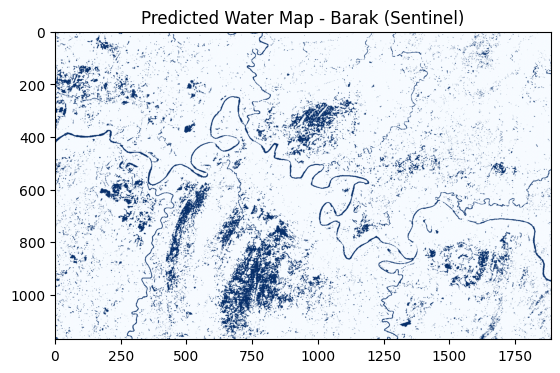

In [13]:
pred_map_new = predict_full_image(stacked_new, model, patch_size=9)

plt.imshow(pred_map_new, cmap='Blues')
plt.title("Predicted Water Map - Barak (Sentinel)")
plt.show()

In [14]:
plt.savefig("/content/drive/MyDrive/model/out/Sentinelbarak.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [15]:
import rasterio
from rasterio.transform import from_origin

# Output path
output_path = "/content/drive/MyDrive/model/SEN_30_Barak/predicted_water_barak.tif"

# Save GeoTIFF
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=pred_map_new.shape[0],
    width=pred_map_new.shape[1],
    count=1,
    dtype=rasterio.uint8,
    crs=crs_new,
    transform=transform_new
) as dst:
    dst.write(pred_map_new.astype(np.uint8), 1)

print("✅ Saved predicted map at:", output_path)

✅ Saved predicted map at: /content/drive/MyDrive/model/SEN_30_Barak/predicted_water_barak.tif


Test on Chaparmukh

In [16]:
import rasterio
from rasterio.transform import array_bounds

band_path = "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b1.tif"

with rasterio.open(band_path) as src:
    transform = src.transform
    crs = src.crs
    height = src.height
    width = src.width

# Get bounds
bounds = array_bounds(height, width, transform)

print("=== Raster Info ===")
print("CRS:", crs)
print("Height:", height)
print("Width :", width)

print("\n=== Raster Bounds ===")
print("Min Lon:", bounds[0])
print("Min Lat:", bounds[1])
print("Max Lon:", bounds[2])
print("Max Lat:", bounds[3])

=== Raster Info ===
CRS: EPSG:32646
Height: 290
Width : 419

=== Raster Bounds ===
Min Lon: 446240.0
Min Lat: 2893840.0
Max Lon: 458810.0
Max Lat: 2902540.0


In [17]:
from pyproj import Transformer

# Your bounds (UTM)
min_x, min_y = 446240.0, 2893840.0
max_x, max_y = 458810.0, 2902540.0

# Convert EPSG:32646 → EPSG:4326
transformer = Transformer.from_crs("EPSG:32646", "EPSG:4326", always_xy=True)

min_lon, min_lat = transformer.transform(min_x, min_y)
max_lon, max_lat = transformer.transform(max_x, max_y)

print("=== Converted Bounds (WGS84) ===")
print("Min Lon:", min_lon)
print("Min Lat:", min_lat)
print("Max Lon:", max_lon)
print("Max Lat:", max_lat)

=== Converted Bounds (WGS84) ===
Min Lon: 92.46207782363383
Min Lat: 26.162940969099843
Max Lon: 92.58757347366245
Max Lat: 26.241911437787678


In [18]:
import rasterio
import numpy as np

band_paths_new = [
    "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b1.tif",
    "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b2.tif",
    "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b3.tif",
    "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b4.tif",
    "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b8.tif",
    "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b11.tif",
    "/content/drive/MyDrive/model/SEN_30_Chaparmukh/b12.tif",
]

bands_new = []

for path in band_paths_new:
    with rasterio.open(path) as src:
        bands_new.append(src.read(1).astype(np.float32))
        transform_new = src.transform
        crs_new = src.crs

stacked_new = np.stack(bands_new, axis=-1)

print("Stacked shape:", stacked_new.shape)

Stacked shape: (290, 419, 7)


In [19]:
import cv2

def clahe(image):
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(image)

enhanced_new = np.zeros_like(stacked_new, dtype=np.uint8)

for i in range(stacked_new.shape[2]):
    band = stacked_new[:,:,i]

    band_min, band_max = band.min(), band.max()
    if band_max > band_min:
        band_8bit = ((band - band_min) * 255 / (band_max - band_min)).astype(np.uint8)
    else:
        band_8bit = band.astype(np.uint8)

    enhanced_new[:,:,i] = clahe(band_8bit)

stacked_new = enhanced_new

In [20]:
with rasterio.open("/content/drive/MyDrive/model/SEN_30_Chaparmukh/Chaparmukh_DW_WaterMask_Exact.tif") as src:
    water_mask_new = src.read(1)

print("Mask shape:", water_mask_new.shape)
print("Image shape:", stacked_new.shape[:2])

Mask shape: (294, 420)
Image shape: (290, 419)


In [21]:
import cv2

if water_mask_new.shape != stacked_new.shape[:2]:
    water_mask_new = cv2.resize(
        water_mask_new,
        (stacked_new.shape[1], stacked_new.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

In [22]:
def generate_training_patches(image, mask, patch_size=9):
    half = patch_size // 2
    h, w, c = image.shape

    patches = []
    labels = []

    for i in range(half, h-half):
        for j in range(half, w-half):
            patch = image[i-half:i+half+1, j-half:j+half+1, :]
            label = mask[i, j]

            if patch.shape == (patch_size, patch_size, c):
                patches.append(patch)
                labels.append(label)

    return np.array(patches), np.array(labels)


X_new, y_new = generate_training_patches(stacked_new, water_mask_new, patch_size=9)

X_new = X_new.astype(np.float32) / 255.0

print("Patches:", X_new.shape)

Patches: (115902, 9, 9, 7)


In [23]:
max_samples = 4000

if len(X_new) > max_samples:
    idx = np.random.choice(len(X_new), max_samples, replace=False)
    X_new = X_new[idx]
    y_new = y_new[idx]

print("Samples used:", len(X_new))

Samples used: 4000


In [24]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/model/msa.h5", compile=False)

batch_size = 1024
y_probs_list = []

for i in range(0, len(X_new), batch_size):
    batch = X_new[i:i+batch_size]
    preds = model.predict(batch, verbose=0).flatten()
    y_probs_list.append(preds)

y_probs = np.concatenate(y_probs_list)

threshold = 0.55
y_pred = (y_probs > threshold).astype(int)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, roc_auc_score

acc = accuracy_score(y_new, y_pred)
prec = precision_score(y_new, y_pred)
rec = recall_score(y_new, y_pred)
f1 = f1_score(y_new, y_pred)
iou = jaccard_score(y_new, y_pred)
roc_auc = roc_auc_score(y_new, y_probs)

print("\n=== Chaparmukh Evaluation ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"IoU      : {iou:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")


=== Chaparmukh Evaluation ===
Accuracy : 0.8415
Precision: 0.2256
Recall   : 0.6031
F1 Score : 0.3284
IoU      : 0.1965
ROC AUC  : 0.7643


Predicting rows: 100%|██████████| 290/290 [01:35<00:00,  3.05it/s]


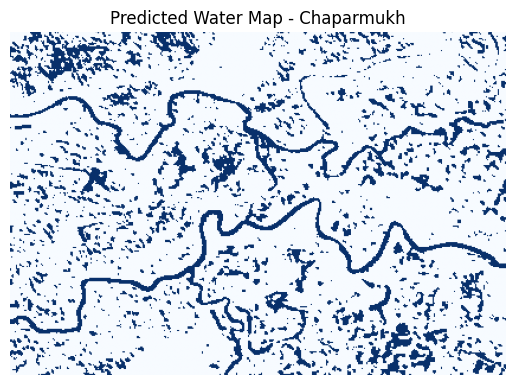

<Figure size 640x480 with 0 Axes>

In [26]:
pred_map_new = predict_full_image(stacked_new, model, patch_size=9)

import matplotlib.pyplot as plt

plt.imshow(pred_map_new, cmap='Blues')
plt.title("Predicted Water Map - Chaparmukh")
plt.axis('off')
plt.show()
plt.savefig("/content/drive/MyDrive/model/out/chaparmukh.png", dpi=300)

In [27]:
output_path = "/content/drive/MyDrive/model/SEN_30_Chaparmukh/predicted_water_chaparmukh.tif"

with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=pred_map_new.shape[0],
    width=pred_map_new.shape[1],
    count=1,
    dtype=rasterio.uint8,
    crs=crs_new,
    transform=transform_new
) as dst:
    dst.write(pred_map_new.astype(np.uint8), 1)

print("✅ Saved at:", output_path)

✅ Saved at: /content/drive/MyDrive/model/SEN_30_Chaparmukh/predicted_water_chaparmukh.tif
